In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [3]:
img = np.ones((300,300,3),dtype=np.uint8)*255
cv2.rectangle(img,(100,100),(200,200),(255,0,0),3)

h,w = img.shape[:2]

In [5]:
#rotation
center = (h//2,w//2)
angle = 45
rot_matrix = cv2.getRotationMatrix2D(center,angle,1)
rotated = cv2.warpAffine(img,rot_matrix,(w,h))

#translation
tx,ty = 50,30
trans_matrix = np.float32([[1,0,tx],[0,1,ty]])
translated = cv2.warpAffine(img,trans_matrix,(w,h))

#combined 
comb_matrix = rot_matrix.copy()
comb_matrix[0,2] += tx
comb_matrix[1,2] += ty
combined = cv2.warpAffine(img,comb_matrix,(w,h))


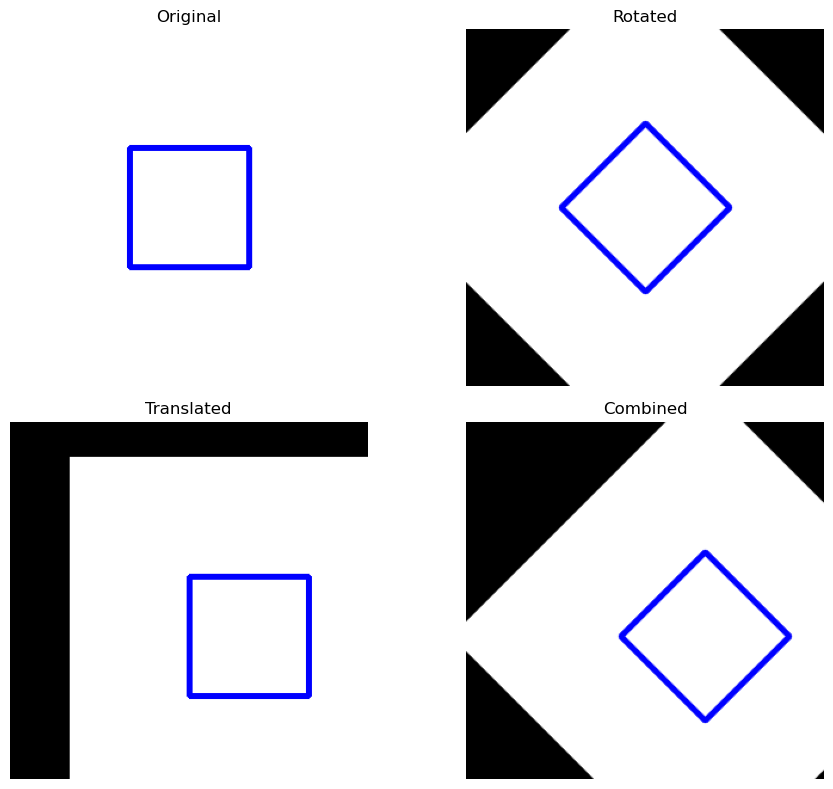

In [ ]:
#plotting
fig,ax = plt.subplots(2,2,figsize=(10,8))
ax[0, 0].imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
ax[0, 0].set_title("Original")

ax[0, 1].imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
ax[0, 1].set_title("Rotated")

ax[1, 0].imshow(cv2.cvtColor(translated, cv2.COLOR_BGR2RGB))
ax[1, 0].set_title("Translated")

ax[1, 1].imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
ax[1, 1].set_title("Combined")

for a in ax.ravel():
    a.axis('off')

plt.tight_layout()
plt.show()